# Exercises 9

## Travelling Salesman Problem

The traveling salesman problem (TSP) consists of a salesman and a set of $N$ cities with positions $\vec{c}_i$. The salesman **has to visit each one of the cities starting from a certain one and returning to the same city**. The challenge of the problem is that the traveling salesman wants to **minimize the total length of the trip**.

For the total length is calculated as:
$$
L^{(1)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N) = \sum_{i=1}^{N} |\vec{x}_i-\vec{x}_{i+1}|
$$
where $\vec{x}_i$ (with $\vec{x}_{N+1}=\vec{x}_1$) is one particular permutation, P, of the ordered sequence of cities $\vec{c}_1, \vec{c}_2, \dots, \vec{c}_N$, i.e. 

$$
\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N = \vec{c}_{P_1}, \vec{c}_{P_2}, \dots, \vec{c}_{P_N}
$$

### Path Representation

I decided to express any possible path with a 1D ordered vector. The elements are integers representing the unique identifier (UID) of the cities, the order from first to last gives the cities the salesman would visit, coming back to the first at the end.

For example for $N=34$ one can represent the path as: $[1, 4, 8, 34, 2, 28, 24, 18, 23, 21, 7, 27, 13, 6, 32, 16, 14, 10, 19, 29, 17, 15, 30, 25, 33, 22, 20, 9, 5, 12, 3, 26, 11, 31]$.

### Genetic Algorithm

To solve the TSP I implemented a Genetic Algorithm (GA), this algorithm treats the 1D path like a chromosome, then generates $M$ multiple paths to form a population and then generate a new population to try improve the current result. Every iteration of the algorithm makes a new generations with 3 main steps: *selection*, *crossover* and *mutation*. 

#### Selection

The selection step is necessary to simulate **genetic pressure**: only the fit organism can reproduce.

To implement a selection I ordered the population from best to worst, and selected two individuals at the index $j_{1/2} = \text{floor}(M \times r^p)$ (with $j_1 \neq j_2$) where $r$ is a uniform random number $r\in[0,1)$, and $p$ is a convenient exponent we can tune to favor the reproduction of some individuals. 

We can make some estimates of reproduction rates:
- for $p = 2$ we get: the best $1\%$ of individuals have a $\sim 10\%$ reproduction rate (r.r.), the $10\%$ best have a total of $\sim 30\%$ r.r., and the worst $50\%$ have a total of $\sim 30\%$ r.r..
- or $p = 7$ we get: the best $1\%$ of individuals have a $\sim 50\%$ r.r., the $10\%$ best have a total of $\sim 70\%$ r.r., and the worst $50\%$ have a total of $\sim 10\%$ r.r..
In this way the best individuals have more chances to reproduce, which are the most likely to improve the result.

In the simulation i will increase $p = 2 \mapsto 7$ linearly with generations, in order to increase the genetic pressure with time.

Note: if we decided to order the population from worst to best we would get a different curve for $j$, for $0 < p < 1$ this different interpretation gives a reproduction rate similar for the best individuals, but gives a r.r. probability near zero for the worst individuals. Effectively "killing" the worst individuals. This different approach was not used in the simulation.

#### Crossover

After choosing the individuals to reproduce there is a fixed probability $p_\text{cross.} = 60\%$ this individuals undergo a crossover operation to create 2 offsprings, otherwise the offsprings are the same as the parents.

The crossover operation follows the steps:
1. select a cut point between $1$ and $N-1$ included.
2. copy the chromosome of the first (and second) parent to the first (second) offspring until the cut point.
3. fill the rest of the chromosome with the missing cities UIDs using the order of the other parent.

In this way we can generate new individuals with some similarities to the parents, but with a different genetic code.

#### Mutations

After the creation of the offsprings there is a fixed probability this individuals develop a mutation, the applied mutations are:
- swap mutation: which swaps two cities in the path, with a probability $p_\text{swap}$. This probability is applied multiple times to allow for more than one swap per mutation.
- shift mutation: chooses a block of $m < N$ contiguous cities, choose a shift $n < m$ and reorders the last $n$ of the block at its beginning. This mutation is applied with probability $p_\text{shift}$.
- permute mutation: chooses two blocks of $m < N/2$ contiguous cities and swaps them with probability $p_\text{permute}$.
- invert mutation: chooses a block of $m < N$ contiguous cities and inverts their order with probability $p_\text{invert}$.

After the mutations are applied, the 2 offsprings are saved to the new generation and the Selection, Crossover and Mutations steps are repeated until we have $M$ individuals in the population. Then we can repeat the whole process for multiple generations, in the simulated I used a total of 1000 generations and 100 individuals.

##### Mutation Size Bias and Non-Convergence

From a biological perspective, small mutations are generally more likely to occur, since large mutations tend to be highly disruptive to an organism’s genetic structure. I initially tried to reproduce this behavior in the algorithm by favoring small mutations over large ones. However, after implementing this approach, I observed that in 20–30% of the runs the algorithm failed to converge properly, often producing significantly suboptimal solutions even for the simple circular city configuration.

After some tests i noted that inversion and shift mutations **need** to make big mutations to properly converge. The permute mutation seems to not suffer the same problem, instead it prefers smaller mutations.

For this reason I decided to use a uniform distribution for the sizes of the inversion mutations and shift mutation so both large and small mutations have the same probability to occur. And use a triangular distribution for the permutation mutation. 

Testing the new mutations on different seeds seemed to have solved the convergence problem. 

## Documentation 

This exercises and the exercises 10 are fully documented: one can fine the [pdf version](https://github.com/Mattia04/LSN/blob/main/Exercises/Exercises_10/docs/latex/refman.pdf) or the [web version](https://mattia04.github.io/LSN/index.html).

### Results

Below I show the results of the simulation using $N = 34$ cities for both the circular configuration and the square configuration. The simulation used 100 individuals for $N_\text{gen.}=1000$ generations, mutation probabilities: $p_\text{swap} = 0.005$ (applied $N-1$ times), $p_\text{shift} = 0.08$, $p_\text{permute} = 0.08$, $p_\text{invert} = 0.08$ and crossover probability $p_\text{cross.} = 0.6$; also the exponent of the selection was chosen as $p = 2 + t * 5 / N_\text{gen.}$.

In [1]:
# Imports
from cycler import cycler

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

from adjustText import adjust_text
import scienceplots

plt.style.use(["science", "ieee"])

colors = plt.cm.Set2.colors
plt.rcParams["axes.prop_cycle"] = cycler(color=colors)

plt.rcParams["figure.dpi"] = 300

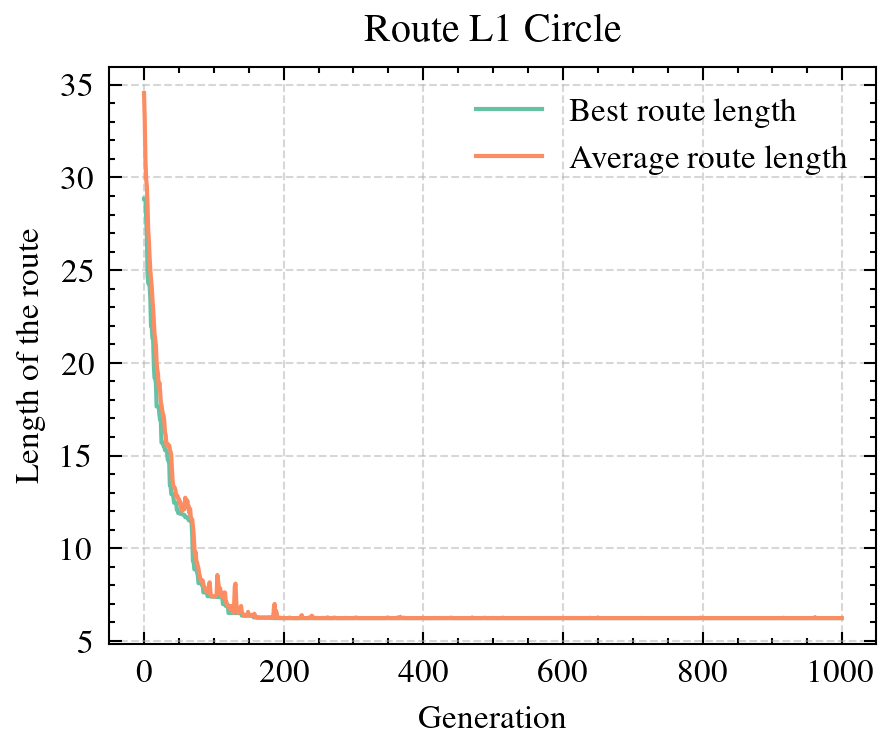

In [2]:
data = np.loadtxt("./data/route_L1_circle.dat", skiprows=1)

plt.plot(data[:, 0], label="Best route length")
plt.plot(data[:, 1], label="Average route length")

plt.title("Route L1 Circle")
plt.xlabel("Generation")
plt.ylabel("Length of the route")

plt.legend()
plt.grid(True, which="major", alpha=0.7)
plt.grid(True, which="major", alpha=0.5, ls="--")

plt.show()

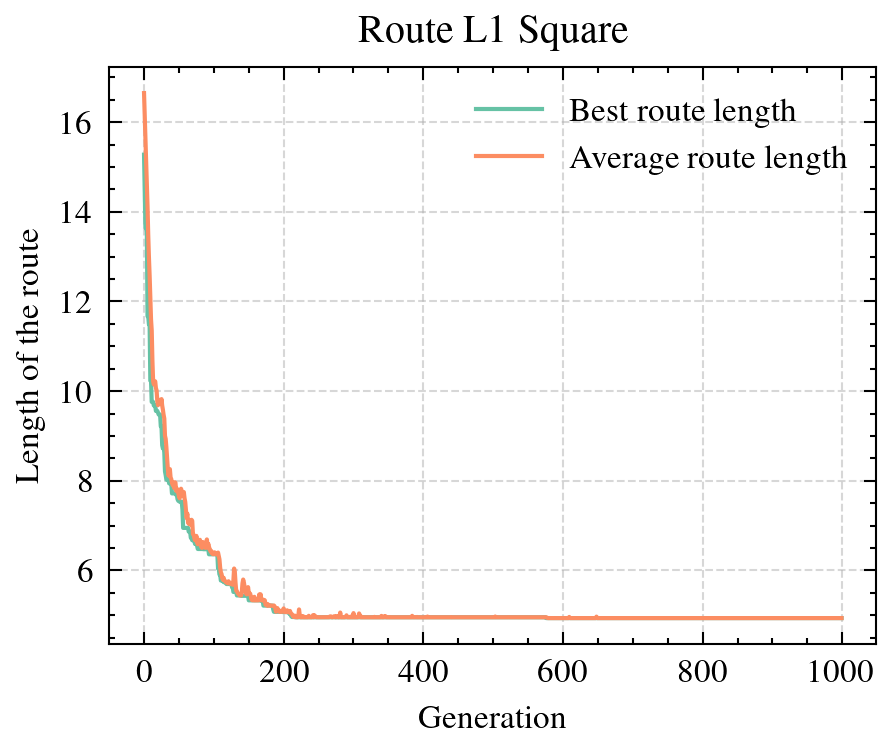

In [3]:
data = np.loadtxt("./data/route_L1_square.dat", skiprows=1)

plt.plot(data[:, 0], label="Best route length")
plt.plot(data[:, 1], label="Average route length")

plt.title("Route L1 Square")
plt.xlabel("Generation")
plt.ylabel("Length of the route")

plt.legend()
plt.grid(True, which="major", alpha=0.7)
plt.grid(True, which="major", alpha=0.5, ls="--")

plt.show()

In [4]:
def make_visualization(config="circle"):
    data = np.loadtxt(f"./data/map_{config}.dat", skiprows=1)

    uids = data[:, 0].astype(int)
    x_coords = data[:, 1]
    y_coords = data[:, 2]

    # Create the plot
    fig, ax = plt.subplots(figsize=(5, 5))

    # Add unit circle (radius 1)
    if config == "circle":
        theta = np.linspace(0, 2 * np.pi, 500)
        circle_x = np.cos(theta)
        circle_y = np.sin(theta)
        ax.plot(circle_x, circle_y, linewidth=2, label="Unit Circle")

    # Plot cities
    ax.scatter(x_coords, y_coords, s=20, label="Cities", c="C1", zorder=3)

    # Add city labels
    texts = []
    for uid, x, y in zip(uids, x_coords, y_coords):
        texts.append(ax.text(x, y, str(uid), fontsize=8, alpha=0.7))

    adjust_text(
        texts,
        arrowprops=dict(arrowstyle="->", lw=0.5, alpha=0.5),
        min_arrow_len=30,
        force_points=(0.5, 0.5),
    )

    # Load the best route
    route = np.loadtxt(f"./data/best_route_{config}.dat", dtype=int)

    # Create a mapping from uid to coordinates
    uid_to_coords = {uid: (x, y) for uid, x, y in zip(uids, x_coords, y_coords)}

    # Plot the final route (last frame)
    final_route = route[-1]  # Get the last route
    coords = np.array([uid_to_coords[uid] for uid in final_route])

    ax.plot(
        coords[:, 0],
        coords[:, 1],
        linewidth=1.5,
        alpha=0.6,
        label="Best Route",
        c="C2",
        zorder=2,
    )

    # Styling
    ax.set_aspect("equal")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title(
        f"Cities Distributed {"on the Unit Circle" if config == "circle" else "inside a Square"} - Final Route"
    )
    ax.grid(True)
    ax.legend()

    plt.show()

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


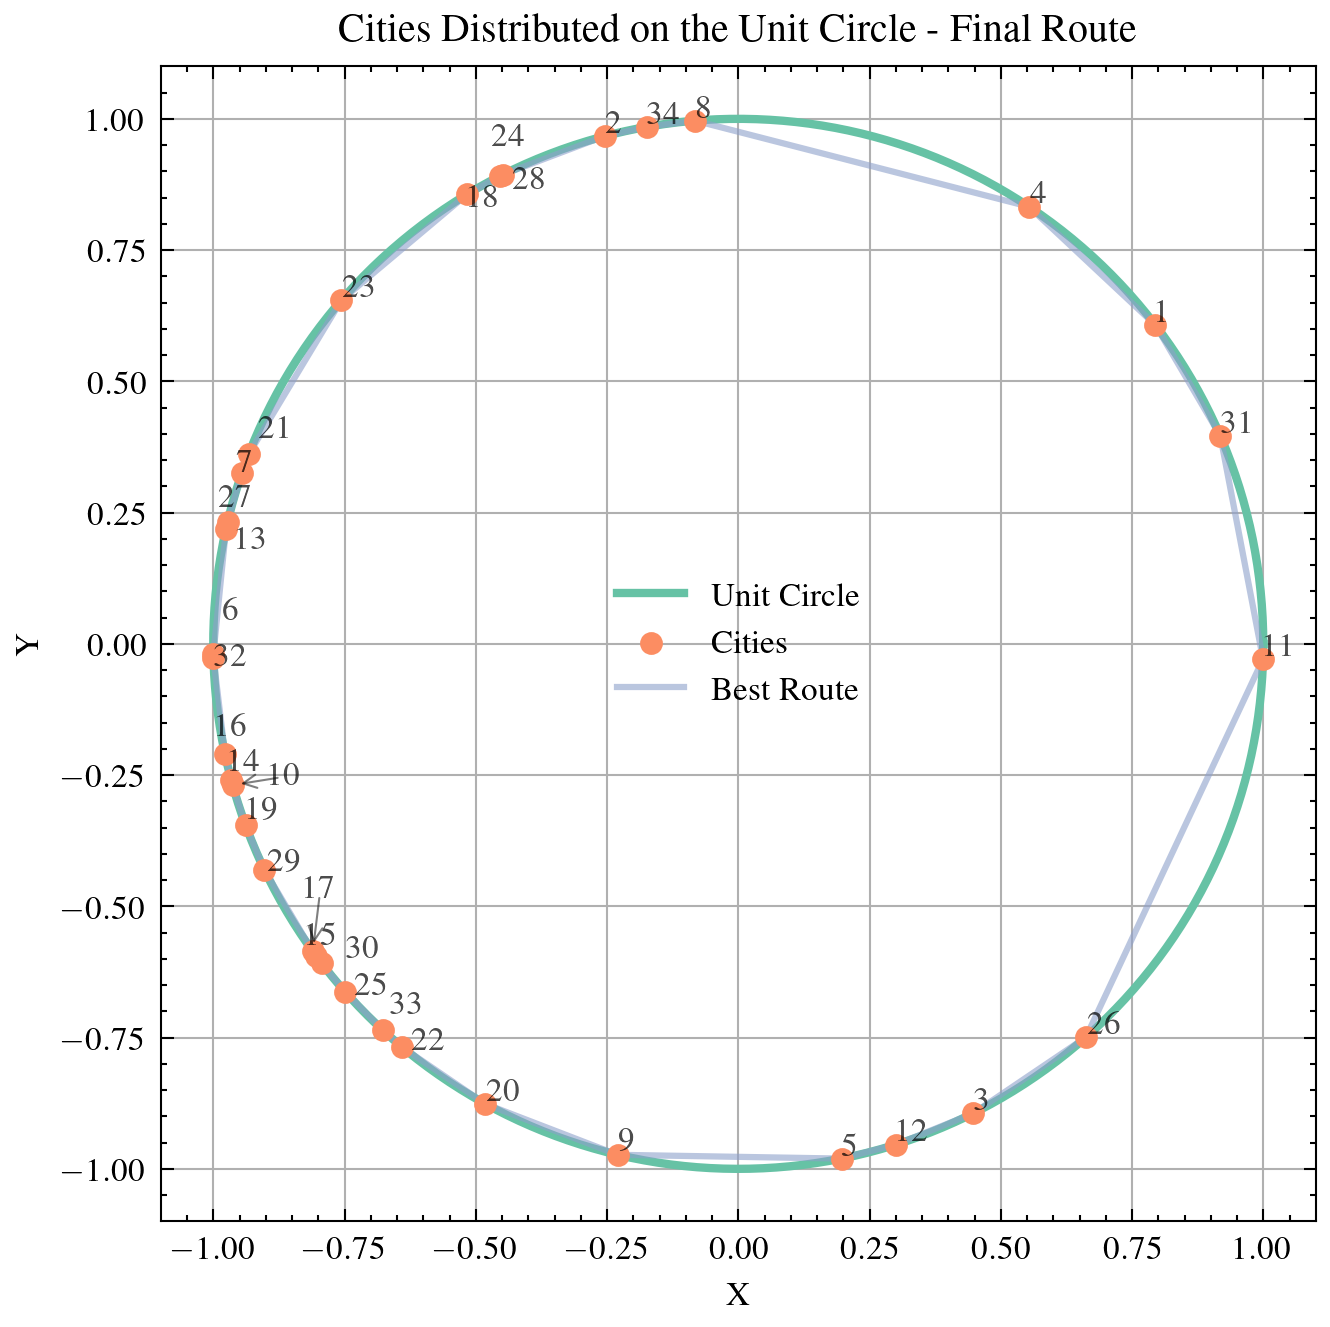

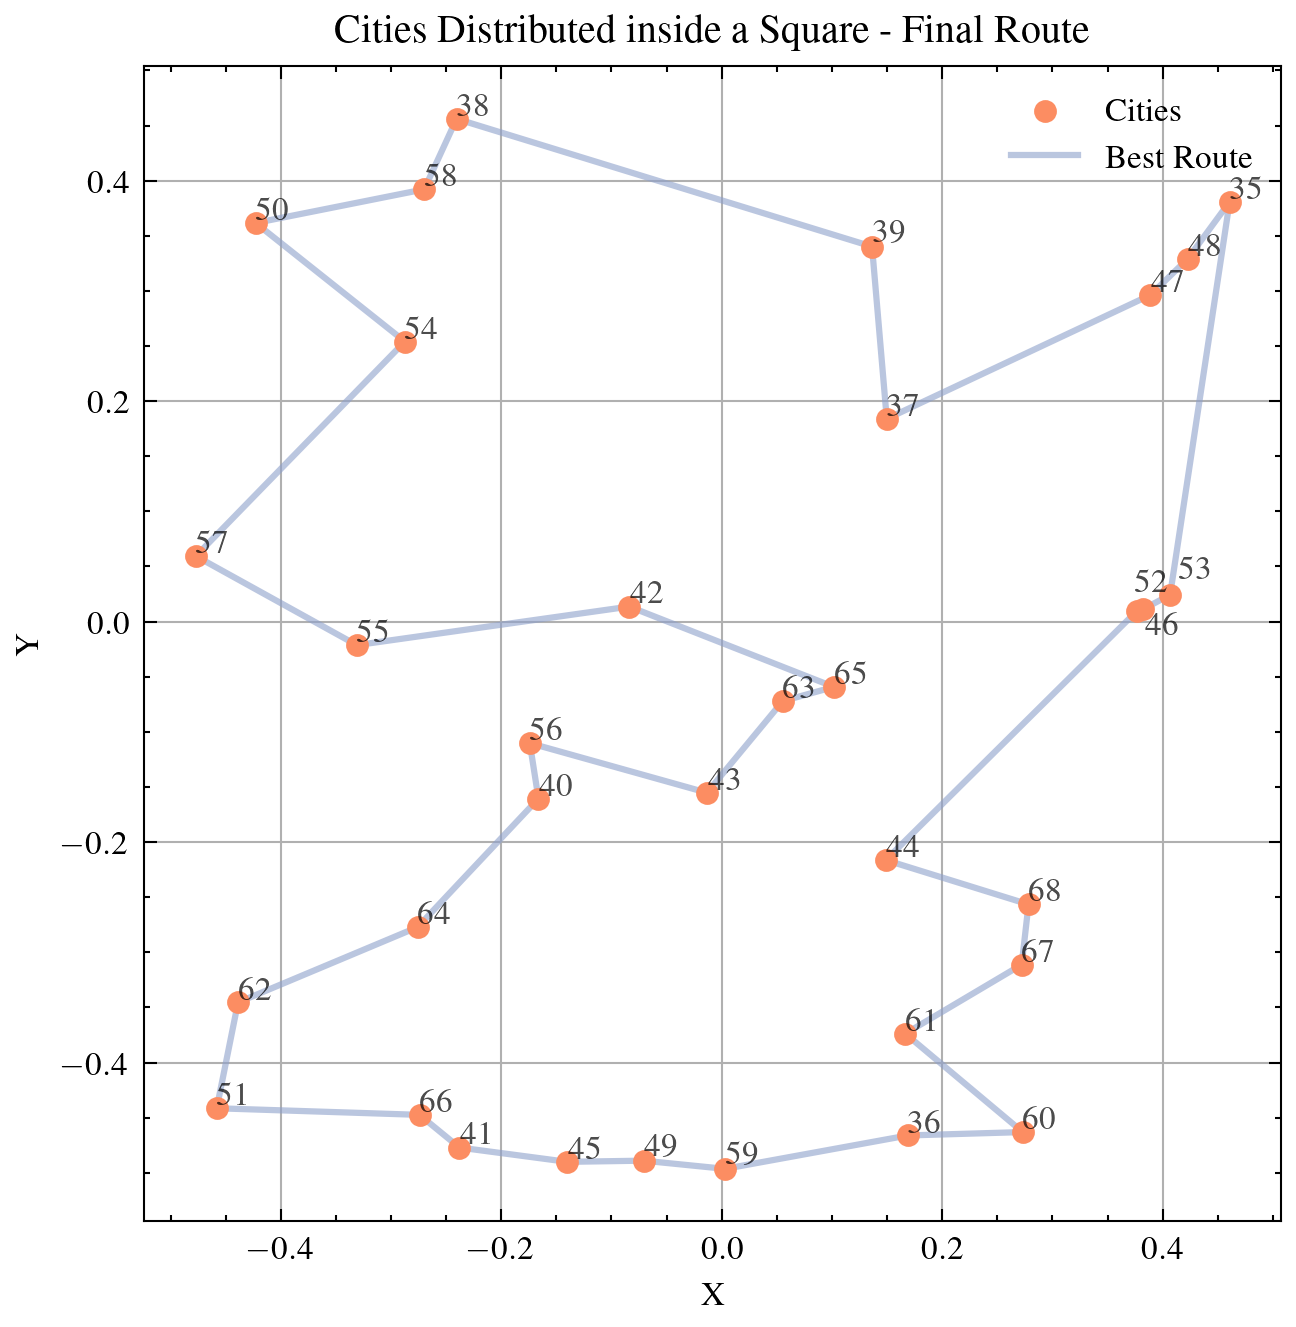

In [5]:
make_visualization("circle")
make_visualization("square")

## Just for fun: Animations!

Below is a script to make a short animation of the best path changing over generations.

In [6]:
def make_animation(config="circle"):
    data = np.loadtxt(f"./data/map_{config}.dat", skiprows=1)

    uids = data[:, 0].astype(int)
    x_coords = data[:, 1]
    y_coords = data[:, 2]

    # Create the plot
    fig, ax = plt.subplots(figsize=(5, 5))

    # Add unit circle (radius 1)
    if config == "circle":
        theta = np.linspace(0, 2 * np.pi, 500)
        circle_x = np.cos(theta)
        circle_y = np.sin(theta)
        ax.plot(circle_x, circle_y, linewidth=2, label="Unit Circle")

    # Plot cities
    ax.scatter(x_coords, y_coords, s=40, label="Cities", c="C1", zorder=3)

    # Add city labels
    texts = []
    for uid, x, y in zip(uids, x_coords, y_coords):
        texts.append(ax.text(x, y, str(uid), fontsize=8, alpha=0.7))

    adjust_text(
        texts,
        arrowprops=dict(arrowstyle="->", lw=0.5, alpha=0.5, shrinkA=2, shrinkB=1),
        min_arrow_len=30,
        force_points=(0.5, 0.5),
    )

    # Load the best route
    route = np.loadtxt(f"./data/best_route_{config}.dat", dtype=int)

    # Create a mapping from uid to coordinates
    uid_to_coords = {uid: (x, y) for uid, x, y in zip(uids, x_coords, y_coords)}

    # Pre-compute all route coordinates
    route_coords = np.array(
        [[uid_to_coords[uid] for uid in route_row] for route_row in route]
    )

    # Initialize line object for animation
    (line,) = ax.plot(
        [], [], linewidth=1.5, alpha=0.6, label="Best Route", c="C2", zorder=2
    )

    # Animation function
    def animate(frame):
        coords = route_coords[frame]
        line.set_data(coords[:, 0], coords[:, 1])

        # Update title to show current iteration
        ax.set_title(
            f"Cities Distributed {"on the Unit Circle" if config == "circle" else "inside a Square"} (Route {frame + 1}/{len(route)})"
        )

        return (line,)

    # Styling
    ax.set_aspect("equal")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

    ax.grid(True)
    ax.legend()

    # Create animation
    anim = FuncAnimation(
        fig, animate, frames=range(0, len(route), 5), interval=1000, blit=True
    )

    # Save as GIF
    writer = PillowWriter(fps=10)
    anim.save(f"routes_animation_{config}.gif", writer=writer, dpi=200)

    plt.close()

In [7]:
make_animation("circle")
make_animation("square")

![Route Circle](./media/routes_animation_circle.gif?t=9)
![Route Square](./media/routes_animation_square.gif?t=9)